# Hafta 2 — Backpropagation Video Anlatımı

> Bu notebook teknik dokümantasyon değil, video sırasında izleyeceğim sade
> anlatım akışıdır. Ayrıntılı hesaplar `backpropagation_calismasi.ipynb`
> dosyasında bulunuyor.

## Açılışta söyleyeceğim

Merhaba, bu hafta geçen hafta sayısal olarak hesapladığım türevleri tek bir
geriye geçişte bulabilmek için küçük bir autograd motoru geliştirdim.

Çalışmaya sayıları ve işlemlerin geçmişini saklayan bir `Value` sınıfıyla
başladım. Daha sonra chain rule kullanarak otomatik `backward()` mekanizmasını
kurdum. Son aşamada bunun üzerine `Neuron`, `Layer` ve `MLP` sınıflarını kurup
küçük bir ağı eğittim.

Anlatım sıram:

```text
Value → Elle gradient → backward() → doğrulama → MLP eğitimi
```

In [1]:
%load_ext autoreload
%autoreload 2

import math
import random
import matplotlib.pyplot as plt

from value import Value, numerical_derivative
from nn import MLP
from train import TARGETS, train_model

# 1. Value ve computation graph

## Anlatırken söyleyeceğim

İlk görevde kendi `Value` sınıfımı yazdım. Normal bir Python sayısı yapılan
işlemin yalnızca sonucunu tutuyor. Backpropagation yapabilmek için sonucun hangi
değerlerden ve hangi işlemden oluştuğunu da bilmemiz gerekiyor.

Bu nedenle her `Value`:

- Sayısal değerini,
- Kendisini üreten önceki `Value` nesnelerini,
- Kullanılan operasyonu,
- Daha sonra hesaplanacak gradient'ini

saklıyor.

Ekranda aşağıdaki küçük ifadeyi göstereceğim. Hesabın sonucu `4`, fakat önemli
olan ara node'ların da kaybolmaması.

In [2]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")

e = a * b
e.label = "e"
result = e + c
result.label = "result"

print("Sonuç:", result.data)
print("Son işlemi:", result._op)
print("Result'ı üreten node'lar:", sorted(node.label for node in result._prev))
print("e'yi üreten node'lar:", sorted(node.label for node in e._prev))

Sonuç: 4.0
Son işlemi: +
Result'ı üreten node'lar: ['c', 'e']
e'yi üreten node'lar: ['a', 'b']


## Çıktıdan sonra söyleyeceğim

Burada final sonuç `4`. `result`, kendisinin `e` ve `c` değerlerinin
toplanmasıyla oluştuğunu biliyor. Ara değer `e` de `a` ve `b`nin çarpımından
oluştuğunu biliyor.

Yani forward pass sırasında yalnızca sonucu değil, geriye doğru takip
edebileceğimiz computation graph'ı da kurmuş oldum.

**Geçiş:** Graph'ı kurduktan sonra sıradaki soru, final output'un her node'dan
ne kadar etkilendiğini bulmaktı.

# 2. Gradient'leri önce elle hesaplamak

## Anlatırken söyleyeceğim

Backward işlemini otomatikleştirmeden önce chain rule'u anlayabilmek için
gradient'leri elle hesapladım.

Kullandığım ifade:

```text
e = a × b
d = e + c
L = d × f
```

Değerleri yerine koyduğumda final sonuç `L=-8` oluyor. Backward pass'e
`L.grad=1` diyerek başladım. Daha sonra her node'da üstten gelen gradient'i o
işlemin local derivative'iyle çarptım.

Toplama node'u gradient'i iki kola aynen gönderiyor. Çarpma node'unda ise bir
girdinin local derivative'i diğer girdinin değerine eşit oluyor.

In [3]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
f = Value(-2.0, label="f")
e = a * b; e.label = "e"
d = e + c; d.label = "d"
L = d * f; L.label = "L"

# Bu değerler bu bölümde elle dolduruluyor.
L.grad = 1.0
d.grad = f.data * L.grad
f.grad = d.data * L.grad
e.grad = d.grad
c.grad = d.grad
a.grad = b.data * e.grad
b.grad = a.data * e.grad

for node in [a, b, c, f, L]:
    print(f"{node.label}: data={node.data:>5.1f}, gradient={node.grad:>5.1f}")

a: data=  2.0, gradient=  6.0
b: data= -3.0, gradient= -4.0
c: data= 10.0, gradient= -2.0
f: data= -2.0, gradient=  4.0
L: data= -8.0, gradient=  1.0


## Gradient’leri insan dilinde yorumlamam

`a.grad=6` olması, `a` değerini çok küçük miktarda artırdığımda `L`nin yaklaşık
altı katı miktarda artacağını söylüyor.

`b.grad=-4` ise `b`yi artırmanın `L`yi azaltacağını gösteriyor. Yani gradient'in
işareti etkinin yönünü, büyüklüğü ise hassasiyetin gücünü gösteriyor.

Tek nöron örneğinde de aynı işlemi yaptım. Nöronun ham ağırlıklı toplamını
`tanh` fonksiyonundan geçirdim. `tanh` çıktıyı `-1` ile `1` arasına getiriyor ve
ağa doğrusal olmayan davranış kazandırıyor.

**Geçiş:** Elle yaptığım bu işlemin her node'da aynı kalıbı tekrar ettiğini
görünce bunu `backward()` içinde otomatikleştirdim.

# 3. Otomatik backward()

## Anlatırken söyleyeceğim

`backward()` önce output'tan erişilebilen bütün node'ları topological sıraya
koyuyor. Daha sonra output gradient'ini `1` yapıp bu sırayı tersine çeviriyor.

Her node kendi local derivative'ini biliyor. Üstten gelen gradient ile local
derivative çarpılıyor ve sonuç önceki node'lara ekleniyor.

Burada “ekleniyor” kelimesi önemli. Aynı değişken graph içinde birden fazla
yerde kullanılırsa gradient birden fazla yoldan gelir. Bu katkıları toplamak
için gradient'leri `=` ile değiştirmek yerine `+=` ile biriktirdim.

In [4]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
f = Value(-2.0, label="f")

L = (a * b + c) * f
L.backward()

print("Otomatik backward sonuçları")
print("a.grad =", a.grad)
print("b.grad =", b.grad)
print("c.grad =", c.grad)
print("f.grad =", f.grad)

x = Value(3.0)
y = x * x
y.backward()
print("\nx=3 için x*x gradient'i =", x.grad)

Otomatik backward sonuçları
a.grad = 6.0
b.grad = -4.0
c.grad = -2.0
f.grad = 4.0

x=3 için x*x gradient'i = 6.0


## Çıktıdan sonra söyleyeceğim

Otomatik sonuçlar elle bulduğum `6, -4, -2 ve 4` değerleriyle aynı çıktı.

İkinci örnekte `x`, `x*x` ifadesinde iki yerde kullanılıyor. `x=3` için türev
`2x=6`. Bu örnek, iki graph yolundan gelen gradient katkılarının toplanması
gerektiğini gösteriyor.

**Geçiş:** Backward sonuçları doğru görünüyordu fakat yalnızca görünmesi yeterli
değildi. Bu nedenle üç bağımsız yöntemle doğruladım.

# 4. `tanh`ı parçalamak ve gradient’i doğrulamak

## Anlatırken söyleyeceğim

`tanh`, nöronun ağırlıklı toplamından sonra kullandığım aktivasyon
fonksiyonudur. Herhangi bir sayıyı `-1` ile `1` arasına getirir ve modele
nonlinearity kazandırır.

İlk uygulamada `tanh`ı tek bir operasyon olarak yazdım. Daha sonra aynı
fonksiyonu şu formülle küçük işlemlere ayırdım:

```text
tanh(x) = (e^(2x)-1) / (e^(2x)+1)
```

Bunu yapabilmek için `exp`, `pow`, çıkarma ve bölme operasyonlarını ekledim.
Buradaki amaç modelde mutlaka parçalanmış `tanh` kullanmak değil. Aynı fonksiyon
farklı computation graph'larla yazıldığında aynı output ve gradient'i alıp
almadığımı görmekti.

In [5]:
input_value = 0.8813735870195432

atomic_x = Value(input_value)
atomic_output = atomic_x.tanh()
atomic_output.backward()

decomposed_x = Value(input_value)
exp_2x = (2 * decomposed_x).exp()
decomposed_output = (exp_2x - 1) / (exp_2x + 1)
decomposed_output.backward()

print(f"Tek parça tanh output:       {atomic_output.data:.10f}")
print(f"Parçalanmış tanh output:     {decomposed_output.data:.10f}")
print(f"Tek parça input gradient:    {atomic_x.grad:.10f}")
print(f"Parçalanmış input gradient:  {decomposed_x.grad:.10f}")

Tek parça tanh output:       0.7071067812
Parçalanmış tanh output:     0.7071067812
Tek parça input gradient:    0.5000000000
Parçalanmış input gradient:  0.5000000000


## Üçlü doğrulama anlatımım

Sonra aynı ifadeyi kendi `backward()` metodumla, geçen haftaki numerical
derivative ile ve PyTorch autograd ile hesapladım.

Numerical derivative, girdiyi çok küçük miktarda sağa ve sola oynatıp output
değişimini ölçerek türevi yaklaşık hesaplıyor. Büyük modelleri eğitmek için
yavaş, fakat backward kodunu kontrol etmek için bağımsız ve faydalı bir yöntem.

In [6]:
x_value = 0.5

micro_x = Value(x_value)
micro_output = (micro_x * micro_x + 2 * micro_x).tanh()
micro_output.backward()

function = lambda x: math.tanh(x*x + 2*x)
numeric_gradient = numerical_derivative(function, x_value)

import torch
torch_x = torch.tensor(x_value, dtype=torch.float64, requires_grad=True)
torch_output = torch.tanh(torch_x * torch_x + 2 * torch_x)
torch_output.backward()

print(f"Kendi backward():      {micro_x.grad:.12f}")
print(f"Numerical derivative: {numeric_gradient:.12f}")
print(f"PyTorch autograd:      {torch_x.grad.item():.12f}")

Kendi backward():      0.841244598541
Numerical derivative: 0.841244598537
PyTorch autograd:      0.841244598541


## Çıktıdan sonra söyleyeceğim

Üç yöntem de yaklaşık `0.8412446` sonucunu verdi. Kendi backward sonucumla
PyTorch tamamen aynı; numerical derivative ile aradaki fark yaklaşık
`4×10⁻¹²`.

Bu eşleşme local derivative'lerin, chain rule'un, topological sıranın ve
gradient biriktirmenin doğru çalıştığını gösteriyor.

**Geçiş:** Autograd motorunu doğruladıktan sonra son görevde bu motorun üzerine
neural network sınıflarını kurdum.

# 5. Neuron, Layer, MLP ve eğitim

## Anlatırken söyleyeceğim

Önce weight, input ve bias değerlerinden `tanh` output'u üreten `Neuron`
sınıfını kurdum. Birden fazla nöronu `Layer`, katmanları sırayla bağlayan yapıyı
ise `MLP` olarak tanımladım.

Kullandığım ağın yapısı `3→4→4→1`. Bu ağda toplam 41 weight ve bias bulunuyor.
Bütün parametreleri tek listede toplayarak aynı gradient descent güncellemesini
hepsine uyguladım.

Her eğitim adımındaki sıra:

```text
forward → loss → zero_grad → backward → update
```

`zero_grad` kritik. Gradient'ler backward sırasında `+=` ile biriktiği için her
yeni eğitim adımından önce eski gradient'leri temizlemezsem geçmiş adımlar da
yeni güncellemeye karışıyor.

Parametre sayısı: 41
İlk loss: 5.230518
Son loss: 0.027169
Hedefler:  [1.0, -1.0, -1.0, 1.0]
Tahminler: [0.9144, -0.9479, -0.8949, 0.9265]


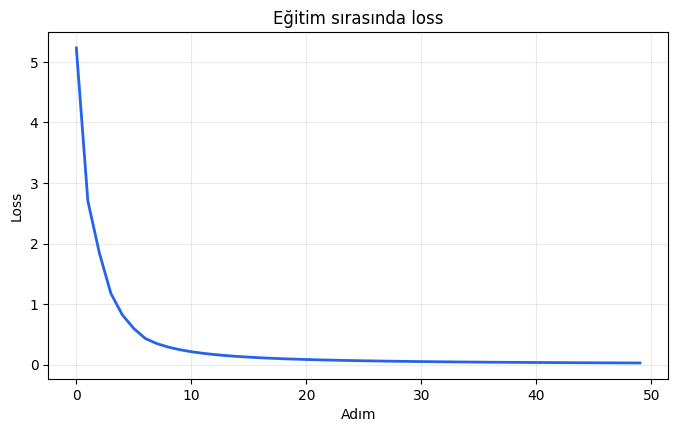

In [7]:
trained_model, loss_history, predictions = train_model(
    steps=50,
    learning_rate=0.05,
    seed=42,
    verbose=False,
)

print("Parametre sayısı:", len(trained_model.parameters()))
print(f"İlk loss: {loss_history[0]:.6f}")
print(f"Son loss: {loss_history[-1]:.6f}")
print("Hedefler: ", TARGETS)
print("Tahminler:", [round(value, 4) for value in predictions])

plt.figure(figsize=(8, 4.5))
plt.plot(loss_history, color="#2563eb", linewidth=2)
plt.title("Eğitim sırasında loss")
plt.xlabel("Adım")
plt.ylabel("Loss")
plt.grid(alpha=0.25)
plt.show()

## Grafikten sonra söyleyeceğim

Başlangıçta loss yaklaşık `5.23`tü. Elli güncelleme sonunda yaklaşık `0.027`ye
düştü. Tahminler de `[1, -1, -1, 1]` hedeflerine yaklaştı.

Burada modelin öğrenmesi, 41 parametrenin loss'u azaltan yönde tekrar tekrar
güncellenmesi anlamına geliyor. Backpropagation hangi yönde ilerlemem
gerektiğini, gradient descent ise bu yönde ne kadar adım atacağımı belirliyor.

# Kapanış

## Söyleyeceğim

Bu çalışma sonunda computation graph'ın forward pass sırasında nasıl
kurulduğunu, chain rule ile gradient'in output'tan input'lara nasıl aktığını ve
bu işlemin ters topological sırada nasıl otomatikleştirildiğini gördüm.

En çok local derivative ile final loss gradient'ini birbirinden ayırırken ve
gradient'lerin neden üzerine yazılmayıp toplanması gerektiğini anlamakta
zorlandım. Elle hesaplarla otomatik sonuçları karşılaştırmak bu ayrımı
oturtmamı sağladı.

Kurduğum sistem küçük ve scalar seviyede olsa da PyTorch autograd ve büyük
neural network'ler aynı temel mekanizmayı kullanıyor. Teşekkürler.

## Takılırsam hatırlayacağım sıra

```text
Graph'ı kurdum
→ Gradient'leri elle anladım
→ backward'ı otomatikleştirdim
→ üç yöntemle doğruladım
→ MLP'yi eğittim
```